В рамках второй части нам нужно сделать EDA и предобработку данных для датасета с изображениями по силе причиненного ущерба автомобилям. Целью EDA является оценить структуру данных, распределить изображения по классам, узнать и привести к одному виду размеры изображений, проверить качество данных и возможные проблемы в них, которые могут повлиять на обучение моделей.

In [44]:
import numpy as np
import imageio.v2 as imageio #https://imageio.readthedocs.io/en/stable/examples.html$0 используем для чтения картинок и выявления их размеров
import os

import torchvision.transforms as transforms
from matplotlib import pyplot as plt
%matplotlib inline

In [7]:
!unzip -q data3a-2.zip -d data3a

In [8]:
base_dir = 'data3a'

os.listdir(base_dir)

['__MACOSX', 'data3a-2']

После распаковки архива видим, что в нем лежит служебная папка моего компьютера '__MACOSX', а также необходимая нам папка с датасетом 'data3a-2'

In [9]:
INPUT_DIR = 'data3a/data3a-2'

os.listdir(INPUT_DIR)

['validation', 'training']

Видим, что в папке данные разделены на две части. Обучающая выборка - 'training' и валидационная - 'validation'.  Это круто, что у нас есть такое распределение, потому что это как раз поможет нам обучить модели на одной части данных и оценить их качество на другой части

In [10]:
train_dir =  os.path.join(INPUT_DIR, 'training')

os.listdir(train_dir) # https://docs-python.ru/standart-library/modul-os-python/funktsija-listdir-modulja-os/$0

['02-moderate', '03-severe', '01-minor']

В обучающей выборке у нас представлены три класса, которые соответсвуют разным уровням степени повреждения автомобиля

In [13]:
num_im = {}
for cl_name in os.listdir(train_dir):
    cl_path= os.path.join(train_dir, cl_name)
    num_im[cl_name]=len(os.listdir(cl_path))

num_im

{'02-moderate': 463, '03-severe': 468, '01-minor': 452}

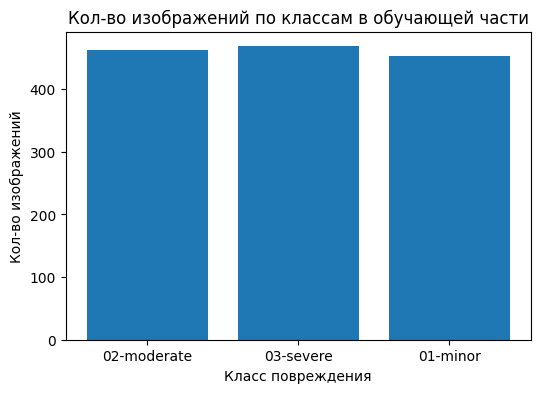

In [47]:
plt.figure(figsize=(6,4))
plt.bar(num_im.keys(),num_im.values())
plt.title('Кол-во изображений по классам в обучающей части')
plt.xlabel('Класс повреждения')
plt.ylabel('Кол-во изображений')

plt.show()

Исходя из графика можем сделать вывод о том, что количество картинок в классах отличается незначительно. То есть можем сделать вывод, что датасет сбалансирован, это хорошо, потому что позволит модели обучаться на всех категориях повреждений без существенного смещения в сторону какого-либо одного класса

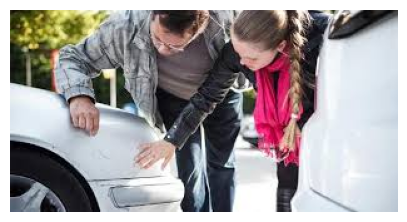

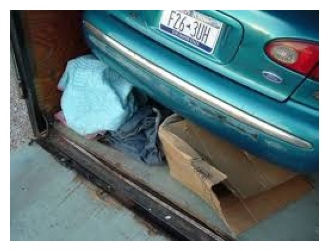

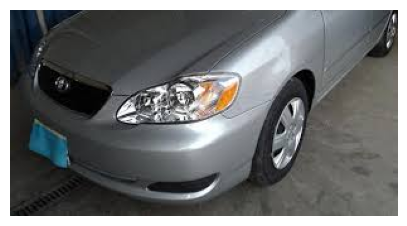

In [23]:
minor_dir = os.path.join(train_dir,'01-minor')
im = os.listdir(minor_dir)

for i in range(3):
    img_path =  os.path.join(minor_dir, im[i])
    img= imageio.imread(img_path)
    plt.figure(figsize=(5,3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

После вывода нескольких изображений из класса minor, видим, что на них прослеживаются незначительные повреждения автомобилей: небольшие вмятины, царапины и тп. То есть картинки верно присвоены к своему классу

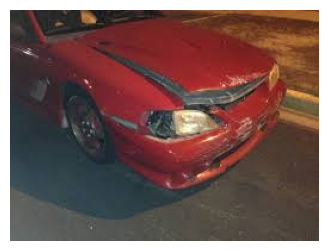

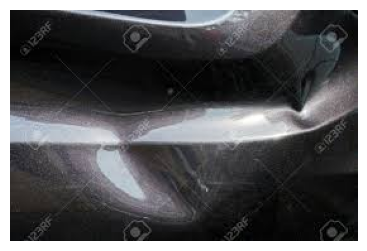

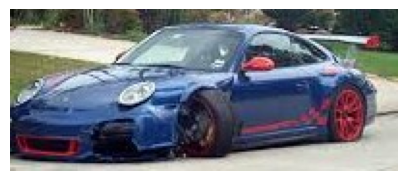

In [26]:
minor_dir = os.path.join(train_dir,'02-moderate')
im = os.listdir(minor_dir)

for i in range(3):
    img_path =  os.path.join(minor_dir, im[i])
    img= imageio.imread(img_path)
    plt.figure(figsize=(5,3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

После вывода нескольких изображений из класса moderate, видим, что на них прослеживаются средней тяжести повреждения автомобилей: сильные вмятины, поломки нескольких частей автомобиля и тп. То есть картинки также верно присвоены к своему классу

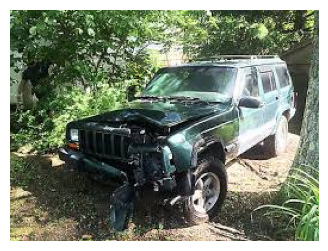

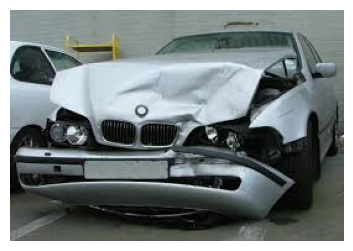

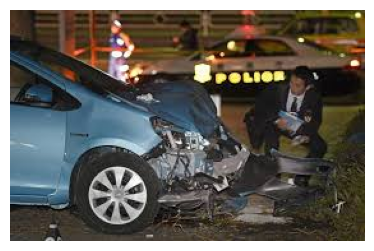

In [25]:
minor_dir = os.path.join(train_dir,'03-severe')
im = os.listdir(minor_dir)

for i in range(3):
    img_path =  os.path.join(minor_dir, im[i])
    img= imageio.imread(img_path)
    plt.figure(figsize=(5,3))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

После вывода нескольких изображений из класса severe, видим, что на них прослеживаются значительные повреждения автомобилей: серьезные деформации автомобилей, крупные поломки и тп. То есть картинки также верно присвоены к своему классу

In [32]:
for cl_name in os.listdir(train_dir) :
    cl_path = os.path.join(train_dir, cl_name)
    print(cl_name)
    for i  in range(3):
        img_name=os.listdir(cl_path)[i]
        img_path=os.path.join(cl_path, img_name)
        img= imageio.imread(img_path)
        print(img.shape)

02-moderate
(194, 259, 3)
(183, 275, 3)
(84, 201, 3)
03-severe
(194, 259, 3)
(187, 270, 3)
(181, 278, 3)
01-minor
(162, 310, 3)
(194, 259, 3)
(164, 308, 3)


Тут мы взяли по три изображения каждого класса и проверили их размерности, оказалось что они везде разные, то есть из этого следует, что нам надо будет привести их к одному размеру. Кроме того, видим, что все они имеют три цветовых канала, то есть rgb

Теперь быстренько пройдемся по валидационной части, посмотрим что у нас там

In [33]:
val_dir= os.path.join(INPUT_DIR, 'validation')
os.listdir(val_dir)

['02-moderate', '03-severe', '01-minor']

Такое же деление по классам как и в тестовой - отлично!

In [34]:
val_num_im = {}
for cl_name in os.listdir(val_dir):
    cl_path = os.path.join(val_dir, cl_name)
    val_num_im[cl_name]= len(os.listdir(cl_path))

val_num_im

{'02-moderate': 75, '03-severe': 91, '01-minor': 82}

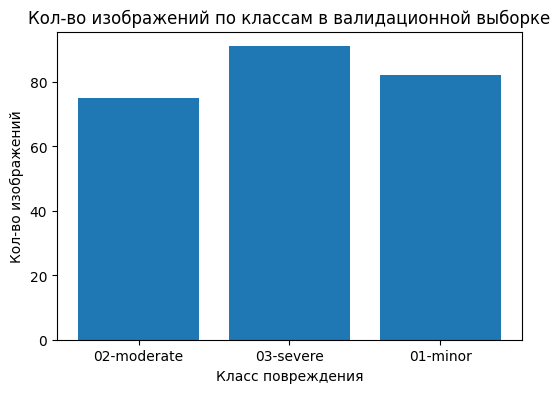

In [36]:
plt.figure(figsize=(6,4))
plt.bar(val_num_im.keys(),val_num_im.values())
plt.title('Кол-во изображений по классам в валидационной выборке')
plt.xlabel('Класс повреждения')
plt.ylabel('Кол-во изображений')

plt.show()

Распределение изображений между классами также достаточно равномерное, то есть дисбаланса не наблюдается

In [41]:
print('training:',  sum(num_im.values()))
print('validation:',  sum(val_num_im.values()))

training: 1383
validation: 248


Датасет содержит 1383 изображения в обучающей выборке и 248 изображений в валидационной

После анализа мы пришлии к следующим выводам: изображения имеют разное разрешение и не могут быть напрямую поданы в нейронку, поэтому перед обучением моделей выполним базовая предобработка данных

In [45]:
transforms.Resize(256)

Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)

Тут мы сделали все картинки сопоставимого размера, это позволит корректно формировать батчи и подавать данные в нейронку

In [46]:
transforms.ToTensor()

ToTensor()

С помощью преобразования этого преобразования изображения стали в формате тензоров PyTorch. Это нужно для будущей обработки данных нейронной сетью и выполнения математических операций над картиночками

В результате EDA мы изучили структуру датасета, распределение изображений по классам в двух выборках, а также сами посмотрели на примеры повреждений разных уровней. Анализ показал, что классы распределены равномерно. Также было выявлено, что изображения имеют разное разрешение, поэтому перед обучением моделей сделали небольшую предобработку: изменили размер изображений и перевели их в формат тензоров